# Fase 2 & 3: Determinación de K y Modelado de Clustering

**Project Terra** — Descubrimiento de ecorregiones agrícolas con aprendizaje no supervisado.

En este notebook:
1. Evaluamos el número óptimo de clústeres ($K$) usando **Método del Codo (Inercia)**, **Coeficiente de Silueta** e **Índice de Davies-Bouldin**.
2. Entrenamos **K-Means** sobre los 7 atributos edafoclimáticos escalados (**el clustering NO se hace sobre PCA**).
3. Proyectamos los clústeres en 2D usando **PCA únicamente con propósitos de visualización interactiva**.
4. Contrastamos las agrupaciones con **Clustering Jerárquico Aglomerativo (Ward)** y dendrograma.
5. Exportamos el dataset enriquecido con las etiquetas de clúster a `data/processed/sensor_Crop_Dataset_clustered.csv`.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import plotly.express as px
import joblib

# Incorporar ruta raíz para importar módulos de src
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.clustering import find_optimal_k, run_kmeans, compute_hierarchical_linkage, run_hierarchical
from src.profiling import plot_pca_clusters

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Carga de Datos
Cargamos los datos limpios y las variables edafoclimáticas escaladas.


In [2]:
raw_path = ROOT_DIR / 'data' / 'raw' / 'sensor_Crop_Dataset.csv'
df = pd.read_csv(raw_path)
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

feature_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
X = df[feature_cols].values

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled.head()


Dataset cargado: 20,000 filas x 10 columnas


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,-0.194526,0.263243,1.267102,-1.014884,0.398209,-1.613560,0.835917
1,0.719418,0.920005,-0.888844,-0.556909,1.706133,-1.500767,-1.061136
2,1.276206,0.802154,-1.034668,0.582042,0.822224,0.060466,-1.162575
3,-1.482386,1.627335,-1.572150,-1.301155,-0.278378,-0.172904,-1.636999
4,-1.322013,1.699590,-0.628804,-1.063698,-0.678517,1.533371,0.766203


## 2. Determinación de K Óptimo
Evaluamos K entre 2 y 8 utilizando 3 criterios complementarios:
- **Inercia (Elbow Method):** Mide la suma de distancias al cuadrado intra-clúster.
- **Silhouette Score:** Mide qué tan similar es un punto a su propio clúster en comparación con otros (mayor es mejor).
- **Davies-Bouldin Index:** Mide la similitud entre cada clúster y su más parecido (menor es mejor).


,k,inertia,silhouette,davies_bouldin
0,2,124895.462512,0.107684,2.827068
1,3,115714.942484,0.093763,2.490192
2,4,108372.864868,0.098616,2.389747
3,5,102840.399765,0.098554,2.149006
4,6,98222.958366,0.099379,1.984155
5,7,93815.230212,0.102908,1.882414
6,8,90020.902265,0.104511,1.777932


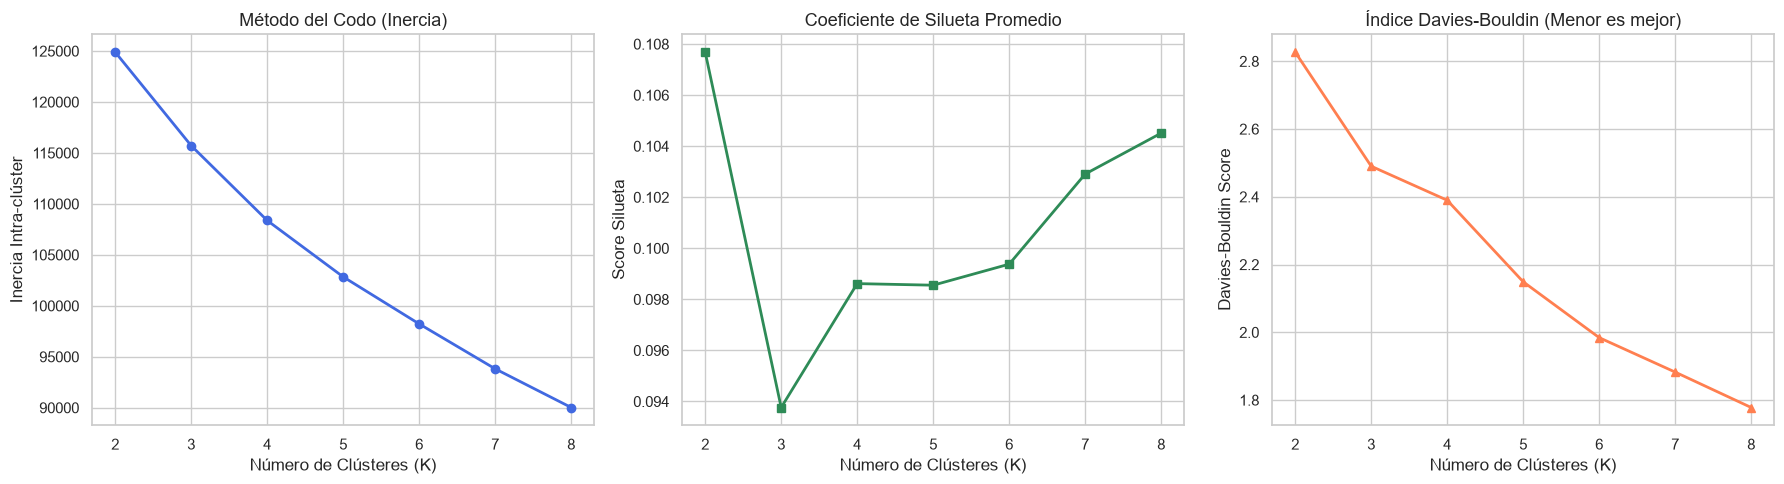

In [3]:
metrics_df = find_optimal_k(X_scaled, k_range=range(2, 9), random_state=42)
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Inercia
axes[0].plot(metrics_df['k'], metrics_df['inertia'], marker='o', color='royalblue', linewidth=2)
axes[0].set_title('Método del Codo (Inercia)', fontsize=13)
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Inercia Intra-clúster')
axes[0].grid(True)

# 2. Silueta
axes[1].plot(metrics_df['k'], metrics_df['silhouette'], marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Coeficiente de Silueta Promedio', fontsize=13)
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Score Silueta')
axes[1].grid(True)

# 3. Davies-Bouldin
axes[2].plot(metrics_df['k'], metrics_df['davies_bouldin'], marker='^', color='coral', linewidth=2)
axes[2].set_title('Índice Davies-Bouldin (Menor es mejor)', fontsize=13)
axes[2].set_xlabel('Número de Clústeres (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 3. Ajuste del Modelo K-Means ($K=5$)
Ajustamos el modelo K-Means sobre las 7 variables escaladas y guardamos los centroides.


In [4]:
k_optimal = 5
kmeans_labels, kmeans_model = run_kmeans(X_scaled, k=k_optimal, random_state=42)

# Inspección de centroides en escala original
centroids_scaled = kmeans_model.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index = [f'Ecorregión {i}' for i in range(k_optimal)]
print('Centroides de las Ecorregiones en escala real:')
display(centroids_df.round(2))


Centroides de las Ecorregiones en escala real:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
Ecorregión 0,78.92,47.55,53.70,27.33,46.88,5.37,242.52
Ecorregión 1,75.32,49.74,79.41,28.52,82.46,6.23,245.35
Ecorregión 2,76.86,47.11,42.38,27.75,60.64,7.54,310.25
Ecorregión 3,78.86,46.07,32.37,26.90,81.27,6.11,146.04
Ecorregión 4,76.23,46.76,65.54,26.54,52.32,7.30,112.06


## 4. Visualización de Clústeres con PCA 2D
> **Nota metodológica crucial:** Como se determinó en la planificación, **el clustering se ejecutó sobre las 7 variables escaladas reales**. Usamos PCA en esta celda únicamente como técnica de proyección geométrica para graficar la distribución multivariada en dos dimensiones.


In [5]:
hover_info = df[['Crop', 'Soil_Type', 'Rainfall', 'Temperature']]
fig_pca, pca_obj = plot_pca_clusters(
    X_scaled=X_scaled,
    labels=kmeans_labels,
    hover_df=hover_info,
    sample_size=3000,
    title='Proyección PCA 2D de las Ecorregiones K-Means'
)
fig_pca.show()


## 5. Clustering Jerárquico Aglomerativo (Ward)
Generamos un dendrograma sobre una muestra representativa para observar la jerarquía de agrupamiento natural y comparamos las asignaciones de K-Means vs Jerárquico.


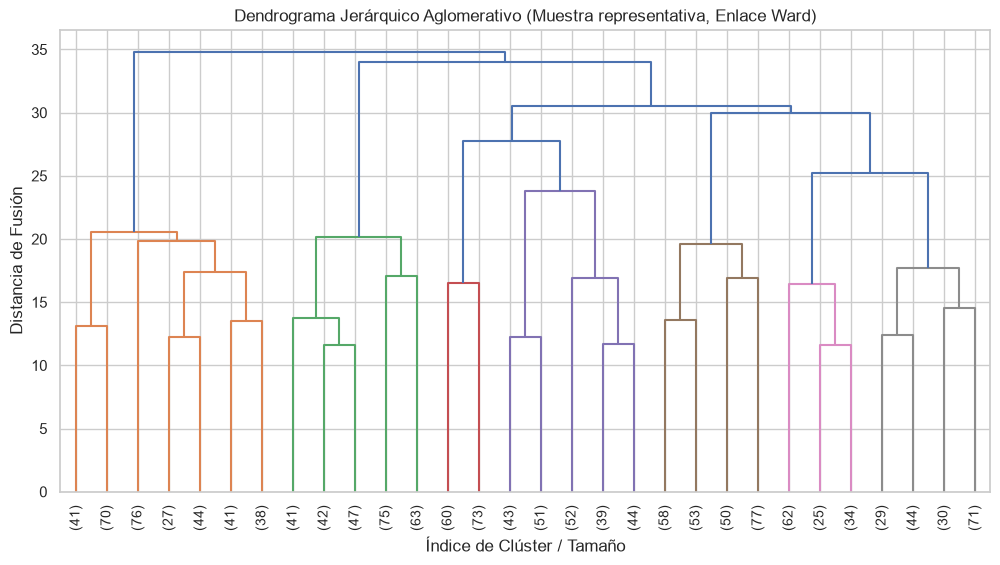

Tabla de Contingencia: K-Means vs. Clustering Jerárquico:


Jerárquico,0,1,2,3,4
K-Means,,,,,
0,1825,804,206,130,1062
1,132,1178,2269,468,201
2,783,1654,1079,64,236
3,726,583,1089,1512,16
4,1926,427,413,409,808


In [6]:
linkage_matrix = compute_hierarchical_linkage(X_scaled, method='ward', sample_size=1500, random_state=42)

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90)
plt.title('Dendrograma Jerárquico Aglomerativo (Muestra representativa, Enlace Ward)')
plt.xlabel('Índice de Clúster / Tamaño')
plt.ylabel('Distancia de Fusión')
plt.show()

# Ajuste jerárquico
hier_labels, _ = run_hierarchical(X_scaled, k=k_optimal, linkage_method='ward')

# Comparación K-Means vs Jerárquico
comparison = pd.crosstab(kmeans_labels, hier_labels, rownames=['K-Means'], colnames=['Jerárquico'])
print('Tabla de Contingencia: K-Means vs. Clustering Jerárquico:')
display(comparison)


## 6. Exportación del Dataset Enriquecido
Agregamos las columnas `kmeans_cluster` y `hierarchical_cluster` al DataFrame y lo guardamos en `data/processed/`.


In [7]:
df['kmeans_cluster'] = kmeans_labels
df['hierarchical_cluster'] = hier_labels

out_path = ROOT_DIR / 'data' / 'processed' / 'sensor_Crop_Dataset_clustered.csv'
df.to_csv(out_path, index=False)
print(f'Dataset exportado exitosamente en: {out_path}')

# Guardar también el modelo y el escalador para la app interactiva
models_dir = ROOT_DIR / 'data' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(kmeans_model, models_dir / f'kmeans_k{k_optimal}.joblib')
joblib.dump(scaler, models_dir / 'scaler.joblib')
print('Modelo y scaler serializados para la app Streamlit.')


Dataset exportado exitosamente en: C:\Users\carli\Documents\Project_Terra\data\processed\sensor_Crop_Dataset_clustered.csv
Modelo y scaler serializados para la app Streamlit.
